
# Explainability visualization for **Multi-Relational Graph Attention KAN**

Notebook này được rút gọn thành đúng **3 tầng giải thích**:

1. **Relation-level**: relation nào quan trọng với từng class?
2. **Node/Subgraph-level**: graph nào, node nào là bằng chứng chính?
3. **Decision-level (KAN head)**: KAN head biến graph embedding thành quyết định như thế nào?

Mục tiêu là tạo ra đúng **3 hình/biểu đồ** dễ hiểu, bám sát narrative của paper:

> **relation → evidence → decision**



## 0. Cấu hình đường dẫn và lựa chọn graph

- Chỉnh `PROJECT_ROOT`, `GRAPH_FOLDER`, `CKPT_PATH`
- Chọn `SPLIT`, `NORMAL_LABEL`, `ATTACK_LABEL`
- Chọn số lượng sample cho relation heatmap
- Chọn graph cụ thể để làm case study và KAN head analysis


In [1]:

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

if '../' not in sys.path:
    sys.path.append('../')
print(sys.path)


['/home/hieutt/CAN-SupCon-IDS/notebooks', '/home/hieutt/miniconda3/envs/torchtf/lib/python39.zip', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/lib-dynload', '', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [2]:

from pathlib import Path
import sys

# =========================
# CHỈNH 4 BIẾN NÀY
# =========================
PROJECT_ROOT = Path('..').resolve()
GRAPH_FOLDER = PROJECT_ROOT / 'data/2017-subaru-forester/graphs_v1_small'
CKPT_PATH = PROJECT_ROOT / 'save/graph_attention_ffn_kan/graph_attention_ffn_kan_best_test_macro_f1.pth'
DEVICE = 'cpu'   # giữ CPU để visualize ổn định

# =========================
# lựa chọn dữ liệu / graph
# =========================
SPLIT = 'test'
NORMAL_LABEL = 'normal'      # nếu không khớp, notebook sẽ tự dò lại
ATTACK_LABEL = None          # ví dụ: 'combined'; None = tự lấy attack đầu tiên khác normal
NORMAL_OCCURRENCE = 0
ATTACK_OCCURRENCE = 0

# =========================
# Section 1: relation-level heatmap
# =========================
MAX_GRAPHS_PER_CLASS = 12    # giảm nếu muốn chạy nhanh hơn
ONLY_CORRECT = True          # chỉ dùng graph model dự đoán đúng để tính relation importance
RELATION_SCORE = 'true_logit_drop'   # hoặc 'pred_prob_drop'

# =========================
# Section 2: node/subgraph-level
# =========================
TOP_K_NODE_LABELS = 8
PLOT_RELATION_FILTER = ('temporal',)  # có thể đổi thành None để vẽ tất cả relation

# =========================
# Section 3: KAN head decision-level
# =========================
KAN_ANALYSIS_GRAPH = 'attack'   # 'attack' hoặc 'normal'
TOP_K_KAN_DIMS = 15
KAN_BG_MAX_SAMPLES = 80         # số graph dùng để tạo histogram embedding dim
KAN_BG_SAME_LABEL_ONLY = True   # histogram chỉ lấy graph cùng label với graph đang phân tích

MODEL_MODULE = 'networks.graph_attention_ffn_kan'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('GRAPH_FOLDER =', GRAPH_FOLDER)
print('CKPT_PATH    =', CKPT_PATH)
print('DEVICE       =', DEVICE)
print('MODEL_MODULE =', MODEL_MODULE)


PROJECT_ROOT = /home/hieutt/CAN-SupCon-IDS
GRAPH_FOLDER = /home/hieutt/CAN-SupCon-IDS/data/2017-subaru-forester/graphs_v1_small
CKPT_PATH    = /home/hieutt/CAN-SupCon-IDS/save/graph_attention_ffn_kan/graph_attention_ffn_kan_best_test_macro_f1.pth
DEVICE       = cpu
MODEL_MODULE = networks.graph_attention_ffn_kan


In [3]:

import os
import json
import math
import importlib
import inspect
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.data import Data
from matplotlib.lines import Line2D

plt.rcParams['figure.dpi'] = 120
sns.set_context('notebook')


## 1. Helper: load metadata, graphs, checkpoint, model

In [4]:

def load_table(base: Path) -> pd.DataFrame:
    pq = base.with_suffix('.parquet')
    csv = base.with_suffix('.csv')
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'Cannot find {pq} or {csv}')


def normalize_label_name(x) -> str:
    return str(x).strip().lower()


def infer_label_mapping(graph_folder: Path) -> Dict[int, str]:
    mapping = {}
    for split in ['train', 'val', 'test']:
        try:
            df = load_table(graph_folder / f'graph_index_{split}')
            if 'y' in df.columns and 'window_label' in df.columns:
                pairs = df[['y', 'window_label']].drop_duplicates()
                for _, row in pairs.iterrows():
                    mapping[int(row['y'])] = str(row['window_label'])
        except Exception:
            continue
    return dict(sorted(mapping.items(), key=lambda kv: kv[0]))


def graph_dict_to_data(graph: dict) -> Data:
    data = Data(
        x=graph['x'].float(),
        edge_index=graph['edge_index'].long(),
        edge_attr=graph['edge_attr'].float(),
        edge_type=graph['edge_type'].long(),
        id_token=graph['id_index'].long(),
        y=graph['y'].view(-1).long(),
    )
    if 'arbitration_id' in graph:
        data.arbitration_id = graph['arbitration_id'].long()
    if 'timestamp' in graph:
        data.timestamp = graph['timestamp'].float()
    if 'msg_idx_in_file' in graph:
        data.msg_idx_in_file = graph['msg_idx_in_file'].long()
    data.graph_id = graph.get('graph_id', 'unknown_graph')
    data.window_label = graph.get('window_label', None)
    data.source_class = graph.get('source_class', None)
    data.meta = graph.get('meta', {})
    return data


def get_graph_label_name(raw_graph: dict, label_mapping: Dict[int, str]) -> str:
    if 'window_label' in raw_graph:
        return str(raw_graph['window_label'])
    y = int(raw_graph['y'].view(-1)[0].item())
    return label_mapping.get(y, f'class_{y}')


def load_graph_metadata(graph_folder: Path) -> Dict[str, Any]:
    meta_path = graph_folder / 'graph_metadata.json'
    if meta_path.exists():
        with open(meta_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {
        'relation_to_index': {'temporal': 0, 'same_id': 1, 'payload_sim': 2, 'timing_aff': 3},
        'index_to_relation': {'0': 'temporal', '1': 'same_id', '2': 'payload_sim', '3': 'timing_aff'},
    }


def infer_num_ids_from_shards(graph_folder: Path) -> int:
    max_id = -1
    for split in ['train', 'val', 'test']:
        split_dir = graph_folder / split
        if not split_dir.exists():
            continue
        for shard_path in sorted(split_dir.glob(f'graphs_{split}_shard*.pt')):
            shard_graphs = torch.load(shard_path, map_location='cpu', weights_only=False)
            for g in shard_graphs:
                if 'id_index' in g:
                    max_id = max(max_id, int(g['id_index'].max().item()))
    if max_id < 0:
        raise RuntimeError('Cannot infer num_ids from shards.')
    return max_id + 1


def iter_raw_graphs(graph_folder: Path, split: str):
    split_dir = graph_folder / split
    shard_paths = sorted(split_dir.glob(f'graphs_{split}_shard*.pt'))
    for shard_path in shard_paths:
        shard_graphs = torch.load(shard_path, map_location='cpu', weights_only=False)
        for raw_g in shard_graphs:
            yield raw_g


def get_split_label_counts(graph_folder: Path, split: str, label_mapping: Dict[int, str]) -> pd.DataFrame:
    df = load_table(graph_folder / f'graph_index_{split}').copy()

    if 'window_label' in df.columns:
        out = (
            df['window_label']
            .astype(str)
            .value_counts()
            .rename_axis('label_name')
            .reset_index(name='count')
        )
    elif 'y' in df.columns:
        out = (
            df['y']
            .astype(int)
            .value_counts()
            .rename_axis('label_id')
            .reset_index(name='count')
        )
        out['label_name'] = out['label_id'].map(label_mapping).fillna(out['label_id'].astype(str))
        out = out[['label_id', 'label_name', 'count']]
    else:
        raise ValueError('graph_index file has neither window_label nor y.')
    return out


def auto_find_normal_label(label_names: List[str]) -> Optional[str]:
    candidates = [str(x) for x in label_names]
    norm_map = {normalize_label_name(x): str(x) for x in candidates}
    for key in ['normal', 'benign', 'non_attack', 'non-attack', 'class_0', '0']:
        if key in norm_map:
            return norm_map[key]
    return None


def select_graph_by_label(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    target_label: str,
    occurrence: int = 0,
) -> Tuple[dict, Data, str]:
    target_norm = normalize_label_name(target_label)
    seen = 0
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if normalize_label_name(label_name) == target_norm:
            if seen == occurrence:
                return raw_g, graph_dict_to_data(raw_g), label_name
            seen += 1
    raise ValueError(f'Cannot find label={target_label} occurrence={occurrence} in split={split}')


def select_first_attack_graph(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    normal_label: str,
    occurrence: int = 0,
) -> Tuple[dict, Data, str]:
    normal_norm = normalize_label_name(normal_label)
    seen = 0
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if normalize_label_name(label_name) != normal_norm:
            if seen == occurrence:
                return raw_g, graph_dict_to_data(raw_g), label_name
            seen += 1
    raise ValueError(f'Cannot find attack graph in split={split}')


def import_model_class(module_name: str):
    mod = importlib.import_module(module_name)
    if not hasattr(mod, 'GraphAttentionKAN'):
        raise ImportError(f'Module {module_name} has no GraphAttentionKAN')
    return mod.GraphAttentionKAN


def build_model_from_checkpoint(ckpt_path: Path, sample_data: Data, graph_folder: Path, device: str = 'cpu', model_module: str = 'networks.graph_attention_ffn_kan'):
    GraphAttentionKAN = import_model_class(model_module)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    args = ckpt.get('args', {})
    label_mapping = ckpt.get('label_mapping', infer_label_mapping(graph_folder))
    num_classes = len(label_mapping)
    num_ids = infer_num_ids_from_shards(graph_folder)

    ctor_kwargs = dict(
        node_feat_dim=int(sample_data.x.size(1)),
        edge_attr_dim=int(sample_data.edge_attr.size(1)),
        num_classes=num_classes,
        num_ids=num_ids,
        hidden_dim=args.get('hidden_dim', 128),
        num_layers=args.get('num_layers', 3),
        heads=args.get('heads', 4),
        id_emb_dim=args.get('id_emb_dim', 32),
        rel_emb_dim=args.get('rel_emb_dim', 8),
        num_relations=args.get('num_relations', 4),
        dropout=args.get('dropout', 0.2),
        ffn_ratio=args.get('ffn_ratio', 2.0),
        block_kan_grid_size=args.get('block_kan_grid_size', 5),
        block_kan_spline_order=args.get('block_kan_spline_order', 3),
        block_kan_scale_noise=args.get('block_kan_scale_noise', 0.1),
        block_kan_scale_base=args.get('block_kan_scale_base', 1.0),
        block_kan_scale_spline=args.get('block_kan_scale_spline', 1.0),
        kan_hidden=args.get('kan_hidden', 128),
        kan_grid_size=args.get('kan_grid_size', 5),
        kan_spline_order=args.get('kan_spline_order', 3),
        kan_scale_noise=args.get('kan_scale_noise', 0.1),
        kan_scale_base=args.get('kan_scale_base', 1.0),
        kan_scale_spline=args.get('kan_scale_spline', 1.0),
    )

    sig = inspect.signature(GraphAttentionKAN.__init__)
    ctor_kwargs = {k: v for k, v in ctor_kwargs.items() if k in sig.parameters}

    model = GraphAttentionKAN(**ctor_kwargs)
    missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
    model = model.to(device).eval()

    print('Loaded checkpoint:', ckpt_path)
    print('Missing keys   :', missing[:10], '...' if len(missing) > 10 else '')
    print('Unexpected keys:', unexpected[:10], '...' if len(unexpected) > 10 else '')
    print('num_classes    :', num_classes)
    print('num_ids        :', num_ids)

    if len(missing) > 0 or len(unexpected) > 0:
        print('⚠️  CẢNH BÁO: model class local và checkpoint chưa khớp hoàn toàn.')
        print('   Hãy restart kernel và đảm bảo file model local đúng bản FFN-KAN / KAN head đã train.')

    return model, ckpt, label_mapping


def forward_logits(model, data: Data, device: str = 'cpu'):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        logits = model(data)
    return logits.cpu()


def get_graph_embedding(model, data: Data, device: str = 'cpu') -> torch.Tensor:
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        try:
            out = model(data, return_graph_embedding=True)
            if isinstance(out, tuple) and len(out) == 2:
                _, g = out
                return g.detach().cpu()
        except TypeError:
            pass
        h = model.encode_nodes(data)
        batch = getattr(data, 'batch', None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)
        return g.detach().cpu()


def get_logits_from_embedding(model, g: torch.Tensor, device: str = 'cpu') -> torch.Tensor:
    model.eval()
    g = g.to(device)
    with torch.no_grad():
        logits = model.head(g)
    return logits.detach().cpu()


In [5]:

graph_meta = load_graph_metadata(GRAPH_FOLDER)
label_mapping = infer_label_mapping(GRAPH_FOLDER)
label_counts = get_split_label_counts(GRAPH_FOLDER, SPLIT, label_mapping)

display(label_counts)
print('label_mapping =', label_mapping)
print('relation mapping =', graph_meta.get('index_to_relation', {}))


,label_name,count
0,normal,13957
1,interval,6363
2,combined,4457
3,speed,1594
4,rpm,1328
5,systematic,987
6,fuzzing,864
7,gear,704
8,dos,667
9,standstill,617


label_mapping = {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}
relation mapping = {'0': 'temporal', '1': 'same_id', '2': 'payload_sim', '3': 'timing_aff'}


In [6]:

available_labels = label_counts['label_name'].astype(str).tolist()

resolved_normal_label = NORMAL_LABEL
if NORMAL_LABEL is None or normalize_label_name(NORMAL_LABEL) not in [normalize_label_name(x) for x in available_labels]:
    auto_label = auto_find_normal_label(available_labels)
    if auto_label is None:
        raise ValueError(f'Cannot resolve NORMAL_LABEL automatically. Available labels: {available_labels}')
    resolved_normal_label = auto_label

print('Resolved NORMAL_LABEL =', resolved_normal_label)

raw_normal, data_normal, normal_label_name = select_graph_by_label(
    GRAPH_FOLDER, SPLIT, label_mapping, resolved_normal_label, occurrence=NORMAL_OCCURRENCE
)

if ATTACK_LABEL is None:
    attack_candidates = [x for x in available_labels if normalize_label_name(x) != normalize_label_name(resolved_normal_label)]
    if len(attack_candidates) == 0:
        raise ValueError('No attack label found in this split.')
    resolved_attack_label = attack_candidates[ATTACK_OCCURRENCE]
else:
    resolved_attack_label = ATTACK_LABEL

raw_attack, data_attack, attack_label_name = select_graph_by_label(
    GRAPH_FOLDER, SPLIT, label_mapping, resolved_attack_label, occurrence=0
)

print('Normal graph:', data_normal.graph_id, '| label =', normal_label_name, '| nodes =', data_normal.x.size(0))
print('Attack graph:', data_attack.graph_id, '| label =', attack_label_name, '| nodes =', data_attack.x.size(0))

model, ckpt, ckpt_label_mapping = build_model_from_checkpoint(
    CKPT_PATH, data_normal, GRAPH_FOLDER, device=DEVICE, model_module=MODEL_MODULE
)


Resolved NORMAL_LABEL = normal
Normal graph: combined__00000384_00000448 | label = normal | nodes = 64
Attack graph: interval__00052416_00052480 | label = interval | nodes = 64
Loaded checkpoint: /home/hieutt/CAN-SupCon-IDS/save/graph_attention_ffn_kan/graph_attention_ffn_kan_best_test_macro_f1.pth
Missing keys   : [] 
Unexpected keys: [] 
num_classes    : 10
num_ids        : 1568



# Phần 1 — Relation-level explanation

**Mục tiêu**: relation nào thực sự quan trọng với từng class?

Ta dùng **relation ablation**:
- giữ nguyên graph
- lần lượt loại bỏ từng relation (`temporal`, `same_id`, `payload_sim`, `timing_aff`)
- đo mức giảm score của class đúng

Hình duy nhất ở phần này là **heatmap class × relation importance**.


In [7]:

DEFAULT_RELATION_TO_INDEX = {'temporal': 0, 'same_id': 1, 'payload_sim': 2, 'timing_aff': 3}
DEFAULT_INDEX_TO_RELATION = {v: k for k, v in DEFAULT_RELATION_TO_INDEX.items()}

def get_relation_mapping(graph_meta):
    idx2rel = graph_meta.get('index_to_relation', {})
    out = {}
    for k, v in idx2rel.items():
        try:
            out[int(k)] = v
        except Exception:
            pass
    if not out:
        out = DEFAULT_INDEX_TO_RELATION
    return out

INDEX_TO_RELATION = get_relation_mapping(graph_meta)
RELATION_TO_INDEX = {v: k for k, v in INDEX_TO_RELATION.items()}


def clone_data(data: Data) -> Data:
    out = Data()
    for k in data.keys():
        v = getattr(data, k)
        if torch.is_tensor(v):
            out[k] = v.clone()
        else:
            out[k] = v
    return out


def ablate_relation(data: Data, relation_idx: int) -> Data:
    out = clone_data(data)
    mask = out.edge_type != int(relation_idx)
    out.edge_index = out.edge_index[:, mask]
    out.edge_attr = out.edge_attr[mask]
    out.edge_type = out.edge_type[mask]
    return out


def score_from_logits(logits: torch.Tensor, target_idx: int, mode: str = 'true_logit_drop') -> float:
    if mode == 'true_logit_drop':
        return float(logits[0, target_idx].item())
    if mode == 'pred_prob_drop':
        prob = torch.softmax(logits, dim=1)
        return float(prob[0, target_idx].item())
    raise ValueError(f'Unknown mode: {mode}')


def collect_relation_importance_matrix(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    relation_to_index: Dict[str, int],
    max_graphs_per_class: int = 12,
    only_correct: bool = True,
    score_mode: str = 'true_logit_drop',
    device: str = 'cpu',
):
    labels_sorted = sorted(label_mapping.items(), key=lambda kv: kv[0])
    label_ids = [k for k, _ in labels_sorted]
    label_names = [v for _, v in labels_sorted]
    rel_names = list(relation_to_index.keys())

    per_class_counts = {lid: 0 for lid in label_ids}
    values = {lid: {r: [] for r in rel_names} for lid in label_ids}

    for raw_g in iter_raw_graphs(graph_folder, split):
        data = graph_dict_to_data(raw_g)
        y = int(data.y.view(-1)[0].item())
        if y not in per_class_counts:
            continue
        if per_class_counts[y] >= max_graphs_per_class:
            continue

        logits = forward_logits(model, data, device=device)
        pred = int(logits.argmax(dim=1).item())
        if only_correct and pred != y:
            continue

        target_idx = y if score_mode == 'true_logit_drop' else pred
        base_score = score_from_logits(logits, target_idx, mode=score_mode)

        for rel_name, rel_idx in relation_to_index.items():
            data_rel = ablate_relation(data, rel_idx)
            logits_rel = forward_logits(model, data_rel, device=device)
            score_rel = score_from_logits(logits_rel, target_idx, mode=score_mode)
            values[y][rel_name].append(base_score - score_rel)

        per_class_counts[y] += 1
        if min(per_class_counts.values()) >= max_graphs_per_class:
            break

    mat = np.full((len(label_ids), len(rel_names)), np.nan, dtype=np.float32)
    count_mat = np.zeros((len(label_ids), len(rel_names)), dtype=np.int32)
    for i, lid in enumerate(label_ids):
        for j, r in enumerate(rel_names):
            arr = values[lid][r]
            if len(arr) > 0:
                mat[i, j] = float(np.mean(arr))
                count_mat[i, j] = len(arr)

    heat_df = pd.DataFrame(mat, index=label_names, columns=rel_names)
    count_df = pd.DataFrame(count_mat, index=label_names, columns=rel_names)
    return heat_df, count_df, per_class_counts

def plot_relation_heatmap(heat_df: pd.DataFrame, title: str = None, save_path: str = None):
    plt.rcParams.update({
        "axes.labelsize": 12,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.titlesize": 14,
        "pdf.fonttype": 42,  # Tránh lỗi Type 3 font khi nộp báo
        "ps.fonttype": 42
    })
    
    # Kích thước biểu đồ tiêu chuẩn
    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.nanmax(np.abs(heat_df.values)) if np.isfinite(heat_df.values).any() else 1.0
    
    # Định dạng lại tên cột và hàng (viết hoa chữ cái đầu, thay '_' bằng dấu cách)
    display_df = heat_df.copy()
    display_df.index = [str(idx).replace('_', ' ').title() for idx in display_df.index]
    display_df.columns = [str(col).replace('_', ' ').title() for col in display_df.columns]

    sns.heatmap(
        display_df,
        annot=True,
        fmt='.2f',          # Rút gọn còn 2 chữ số thập phân cho đỡ rối mắt
        cmap='coolwarm',    # Bảng màu chuyên nghiệp hơn
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=1,       # Viền dày 1px
        linecolor='white',  # Viền trắng để các ô vuông vắn, tách bạch
        cbar_kws={
            'label': 'Score Drop (Impact)', 
            'shrink': 0.85  # Thu ngắn thanh colorbar cho cân đối
        },
        ax=ax
    )
    
    # Tiêu đề (thường báo khoa học không để title trong hình mà để ở caption, 
    # nhưng tôi vẫn giữ lại nếu bạn cần)
    if title:
        plt.title(title, pad=15, fontweight='bold')
        
    plt.xlabel('Relation Type', fontweight='bold', labelpad=10)
    plt.ylabel('Class', fontweight='bold', labelpad=10)
    
    # Căn chỉnh lại nhãn trục X và Y để không bị cắt chữ
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Lưu file chất lượng cao nếu có truyền đường dẫn
    if save_path:
        # Tự động tạo thư mục nếu chưa có
        import os
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f"[*] Saved high-res figure to: {save_path}")
        
    plt.show()
    
    # Reset lại rcParams về mặc định (tránh ảnh hưởng các plot sau nếu không muốn)
    plt.rcdefaults()


[*] Saved high-res figure to: ../figures/explainability/relation_heatmap.pdf


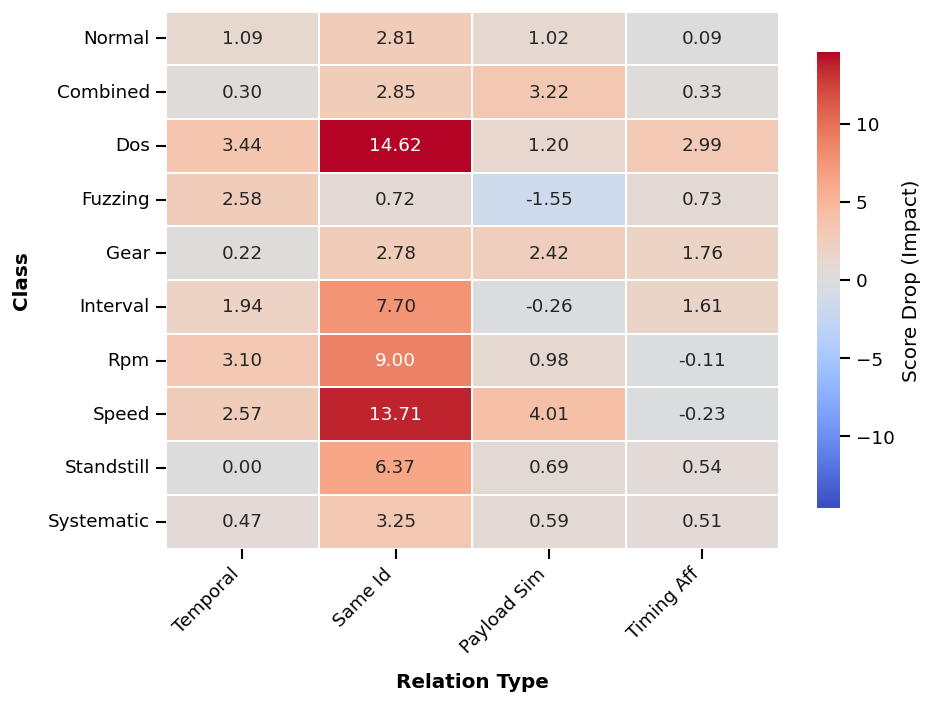

,temporal,same_id,payload_sim,timing_aff
normal,12,12,12,12
combined,12,12,12,12
dos,12,12,12,12
fuzzing,12,12,12,12
gear,12,12,12,12
interval,12,12,12,12
rpm,12,12,12,12
speed,12,12,12,12
standstill,12,12,12,12
systematic,12,12,12,12


Graphs used per class = {0: 12, 1: 12, 2: 12, 3: 12, 4: 12, 5: 12, 6: 12, 7: 12, 8: 12, 9: 12}


In [8]:
relation_heat_df, relation_count_df, per_class_counts = collect_relation_importance_matrix(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    relation_to_index=RELATION_TO_INDEX,
    max_graphs_per_class=MAX_GRAPHS_PER_CLASS,
    only_correct=ONLY_CORRECT,
    score_mode=RELATION_SCORE,
    device=DEVICE,
)

# Thường trong báo khoa học, hình ảnh sẽ được lưu ra file PDF để giữ định dạng vector
plot_relation_heatmap(
    relation_heat_df,
    title=None, # Tắt title vì báo khoa học thường dùng figure caption thay thế
    save_path='../figures/explainability/relation_heatmap.pdf' # Xuất file vector để chèn vào Word/LaTeX
)

display(relation_count_df)
print('Graphs used per class =', per_class_counts)


# Phần 2 — Node/Subgraph-level explanation

**Mục tiêu**: graph nào, node nào là bằng chứng chính?

Ta dùng **node occlusion** trên đúng 2 graph case-study:
- 1 graph `normal`
- 1 graph `attack`

Với mỗi node, ta:
- che node đó (zero features và bỏ các cạnh incident)
- đo mức giảm score của class được dự đoán

Hình duy nhất ở phần này là **2 panel: normal vs attack**, node tô màu theo mức quan trọng.


In [9]:
from typing import Optional, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from torch_geometric.data import Data
import os

def mask_node_and_incident_edges(data: Data, node_idx: int) -> Data:
    out = clone_data(data)
    out.x[node_idx] = 0.0
    incident = (out.edge_index[0] == node_idx) | (out.edge_index[1] == node_idx)
    keep = ~incident
    out.edge_index = out.edge_index[:, keep]
    out.edge_attr = out.edge_attr[keep]
    out.edge_type = out.edge_type[keep]
    return out

def compute_node_occlusion_importance(model, data: Data, device: str = "cpu", target_mode: str = "pred"):
    logits = forward_logits(model, data, device=device)
    pred_idx = int(logits.argmax(dim=1).item())
    true_idx = int(data.y.view(-1)[0].item())
    target_idx = pred_idx if target_mode == "pred" else true_idx
    base_score = float(logits[0, target_idx].item())

    scores = []
    for i in range(data.x.size(0)):
        data_i = mask_node_and_incident_edges(data, i)
        logits_i = forward_logits(model, data_i, device=device)
        score_i = float(logits_i[0, target_idx].item())
        scores.append(base_score - score_i)

    return {
        "base_logits": logits,
        "pred_idx": pred_idx,
        "true_idx": true_idx,
        "target_idx": target_idx,
        "base_score": base_score,
        "importance": np.array(scores, dtype=np.float32),
    }

def build_node_positions(raw_graph: dict):
    node_idx = np.arange(raw_graph["x"].shape[0])

    if "msg_idx_in_file" in raw_graph:
        x = raw_graph["msg_idx_in_file"].cpu().numpy()
    else:
        x = node_idx.astype(np.float32)

    if "arbitration_id" in raw_graph:
        arb = raw_graph["arbitration_id"].cpu().numpy()
        uniq = sorted(np.unique(arb).tolist())
        bucket = {v: i for i, v in enumerate(uniq)}
        y = np.array([bucket[v] for v in arb], dtype=np.float32)
    else:
        y = np.zeros_like(x, dtype=np.float32)

    return x, y

def plot_node_case_panels(
    raw_normal: dict,
    raw_attack: dict,
    imp_normal: np.ndarray,
    imp_attack: np.ndarray,
    normal_title: str = "(a) Normal Traffic",
    attack_title: str = "(b) Attack Traffic",
    relation_filter: Optional[List[str]] = ("temporal",),
    top_k_labels: int = 5,
    figsize=(14, 5.5),
    min_node_size: int = 80,
    max_node_size: int = 400,
    save_path: Optional[str] = None
):
    plt.rcParams.update({
        "axes.labelsize": 12,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.titlesize": 14,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, constrained_layout=True)

    # 2. Thang màu đối xứng (Symmetrical colormap) để nhấn mạnh sự thay đổi (tăng/giảm)
    all_imp = np.concatenate([imp_normal, imp_attack], axis=0)
    vmax = max(abs(np.min(all_imp)), abs(np.max(all_imp)))
    if vmax == 0: vmax = 1e-6
    norm = Normalize(vmin=-vmax, vmax=vmax)
    cmap = plt.cm.coolwarm # Đổi sang coolwarm hiện đại hơn

    # Hàm nội bộ để scale kích thước node theo độ quan trọng (giá trị tuyệt đối)
    def get_node_sizes(imp_array):
        norm_imp = np.abs(imp_array) / vmax
        return min_node_size + norm_imp * (max_node_size - min_node_size)

    panel_specs = [
        (axes[0], raw_normal, imp_normal, normal_title),
        (axes[1], raw_attack, imp_attack, attack_title),
    ]

    for ax, raw_graph, imp, title in panel_specs:
        x, y = build_node_positions(raw_graph)
        edge_index = raw_graph["edge_index"].cpu().numpy()
        edge_type = raw_graph["edge_type"].cpu().numpy()
        arb = raw_graph["arbitration_id"].cpu().numpy() if "arbitration_id" in raw_graph else None

        allowed = None if relation_filter is None else set(relation_filter)
        
        # Lấy top K node quan trọng nhất
        top_nodes = np.argsort(imp)[::-1][:top_k_labels]
        top_node_set = set(top_nodes.tolist())

        # 3. Vẽ đường nối (Làm mờ đi để không gây rối mắt)
        for e in range(edge_index.shape[1]):
            u, v = int(edge_index[0, e]), int(edge_index[1, e])
            rel_name = INDEX_TO_RELATION.get(int(edge_type[e]), f"rel_{int(edge_type[e])}")
            if allowed is not None and rel_name not in allowed:
                continue

            both_top = (u in top_node_set and v in top_node_set)
            color = "#777777" if both_top else "#e0e0e0"
            alpha = 0.6 if both_top else 0.45
            lw = 1.0 if both_top else 0.5
            ls = "-" if both_top else "--"

            ax.plot([x[u], x[v]], [y[u], y[v]], color=color, linewidth=lw, alpha=alpha, linestyle=ls, zorder=1)

        # 4. Vẽ toàn bộ node (Kích thước tự động to/nhỏ theo Importance)
        sizes = get_node_sizes(imp)
        sc = ax.scatter(x, y, c=imp, cmap=cmap, norm=norm, s=sizes, edgecolors="black", linewidths=0.6, zorder=3)

        # 5. Chú thích mũi tên chuyên nghiệp cho Top Nodes
        for n in top_nodes:
            txt = f"N:{n} | ID:{int(arb[n])}" if arb is not None else f"Node {n}"
            # Tính toán offset để mũi tên chạm đúng mép node (khoảng căn bậc 2 của diện tích)
            node_radius_pt = np.sqrt(sizes[n]) / 2 
            
            ax.annotate(
                txt,
                xy=(x[n], y[n]),
                xytext=(0, 25), # Đẩy text lên trên 25 points
                textcoords="offset points",
                fontsize=9,
                ha="center",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9, lw=0.5),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0, shrinkA=0, shrinkB=node_radius_pt + 2),
                zorder=5,
            )

        # Định dạng trục
        ax.set_title(title, pad=12, fontweight='bold')
        ax.set_xlabel("Time Step", fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle=":")
        
        # Bỏ viền trên và phải cho đồ thị thanh thoát
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel("Arbitration ID Buckets", fontweight='bold')

    # 6. Thanh Colorbar chung
    sm = ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("Node Importance (Score Drop)", fontweight='bold', labelpad=10)

    # 7. Lưu file PDF/PNG độ phân giải cao
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f"[*] Saved high-res figure to: {save_path}")

    plt.show()
    plt.rcdefaults() # Reset font về mặc định của Jupyter

In [10]:
res_normal = compute_node_occlusion_importance(
    model,
    data_normal,
    device=DEVICE,
    target_mode="pred",
)

res_attack = compute_node_occlusion_importance(
    model,
    data_attack,
    device=DEVICE,
    target_mode="pred",
)

imp_normal = res_normal["importance"]
imp_attack = res_attack["importance"]

pred_name_normal = label_mapping[res_normal["pred_idx"]]
pred_name_attack = label_mapping[res_attack["pred_idx"]]

print("Normal:", imp_normal.shape, "pred =", pred_name_normal)
print("Attack:", imp_attack.shape, "pred =", pred_name_attack)

Normal: (64,) pred = normal
Attack: (64,) pred = interval


[*] Saved high-res figure to: ../figures/explainability/node_explanation_panels.pdf


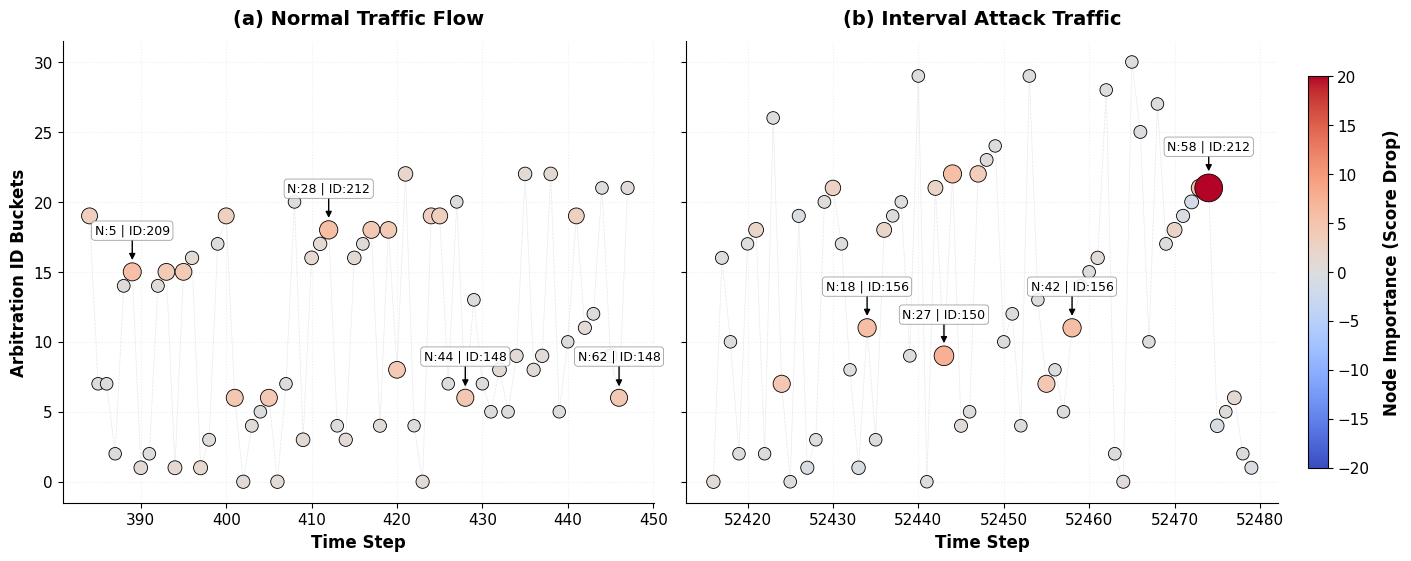

In [11]:
# plot_node_case_panels(
#     raw_normal=raw_normal,
#     raw_attack=raw_attack,
#     imp_normal=imp_normal,
#     imp_attack=imp_attack,
#     normal_title=f"Normal graph | true={normal_label_name} | pred={pred_name_normal}",
#     attack_title=f"Attack graph | true={attack_label_name} | pred={pred_name_attack}",
#     relation_filter=("temporal",),
#     top_k_labels=4,
#     figsize=(18, 6),
#     node_size=140,
# )

plot_node_case_panels(
    raw_normal=raw_normal,
    raw_attack=raw_attack,
    imp_normal=imp_normal,
    imp_attack=imp_attack,
    normal_title="(a) Normal Traffic Flow",
    attack_title="(b) Interval Attack Traffic",
    relation_filter=("temporal",),
    top_k_labels=4,
    figsize=(14, 5.5), # Tỷ lệ chuẩn để nhét vừa lề 2 cột của báo IEEE
    save_path="../figures/explainability/node_explanation_panels.pdf" # Lưu thẳng ra vector PDF
)

# Bạn nên ghi chú thông tin true/pred vào Caption trong file báo cáo, ví dụ: 
# "Figure X: Node-level importance comparison. (a) Normal graph correctly predicted as Normal. (b) Interval attack correctly predicted as Interval. Node sizes correlate with their importance score."


# Phần 3 — Decision-level explanation bằng KAN head

**Mục tiêu**: KAN head biến graph embedding thành quyết định như thế nào?

Ta làm 3 bước:
1. chọn 1 graph để phân tích (`attack` hoặc `normal`)
2. lấy **graph embedding** sau GNN + pooling
3. dùng **gradient × input** để tìm **top-3 embedding dimensions** quan trọng nhất cho class được dự đoán
4. với mỗi dimension, giữ nguyên các dimension khác và chỉ thay đổi dimension đó → vẽ **KAN head response curve**

Hình duy nhất ở phần này là **3 panel response curves** cho top-3 dimensions.


In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from typing import Dict, Any, Optional


def get_graph_embedding(model, data: Data, device: str = "cpu") -> torch.Tensor:
    """
    Returns graph embedding g with no grad, shape [1, D].
    """
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        h = model.encode_nodes(data)
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)

    return g.detach().cpu()


def get_graph_embedding_with_grad(model, data: Data, device: str = "cpu") -> torch.Tensor:
    """
    Returns graph embedding g with grad path preserved, shape [1, D].
    """
    model.eval()
    data = data.to(device)

    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)

    return g


def compute_kan_head_dim_importance(model, data: Data, device: str = "cpu"):
    """
    Importance of each graph-embedding dimension for the predicted class,
    using |grad * input| at the KAN head input.
    """
    model.eval()

    g = get_graph_embedding_with_grad(model, data, device=device)
    g = g.detach().clone().requires_grad_(True).to(device)

    logits = model.head(g)
    pred_idx = int(logits.argmax(dim=1).item())
    score = logits[0, pred_idx]

    grad = torch.autograd.grad(score, g, retain_graph=False, create_graph=False)[0]

    importance = (grad * g).abs().detach().cpu().numpy()[0]
    g_np = g.detach().cpu().numpy()[0]
    logits_np = logits.detach().cpu().numpy()[0]

    return {
        "pred_idx": pred_idx,
        "graph_embedding": g.detach().cpu(),   # [1, D]
        "importance": importance,              # [D]
        "grad": grad.detach().cpu().numpy()[0],
        "g_np": g_np,
        "logits_np": logits_np,
    }


def collect_embedding_background(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    target_label_name: Optional[str] = None,
    max_samples: int = 80,
    device: str = "cpu",
):
    """
    Collect background graph embeddings for histogram plotting.
    If target_label_name is not None, only collect graphs of that label.
    """
    embs = []
    names = []

    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)

        if target_label_name is not None:
            if normalize_label_name(label_name) != normalize_label_name(target_label_name):
                continue

        data = graph_dict_to_data(raw_g)
        g = get_graph_embedding(model, data, device=device)   # [1, D]
        embs.append(g.numpy()[0])
        names.append(label_name)

        if len(embs) >= max_samples:
            break

    if len(embs) == 0:
        raise ValueError("No background embeddings collected.")

    return np.stack(embs, axis=0), names


def sweep_one_embedding_dim_through_head(
    model,
    base_g: torch.Tensor,
    dim_idx: int,
    x_grid_np: np.ndarray,
    device: str = "cpu",
):
    """
    Sweep one graph-embedding dimension while keeping all others fixed.
    Return logits for all classes: shape [N, num_classes]
    """
    model.eval()
    curves = []

    base_g = base_g.clone().detach().to(device)

    with torch.no_grad():
        for val in x_grid_np:
            g = base_g.clone()
            g[0, dim_idx] = float(val)
            logits = model.head(g)   # [1, C]
            curves.append(logits.detach().cpu().numpy()[0])

    return np.stack(curves, axis=0)  # [N, num_classes]


def plot_kan_head_top_dims(
    model,
    base_g: torch.Tensor,
    kan_info: Dict[str, Any],
    bg_embs: np.ndarray,
    label_mapping: Dict[int, str],
    device: str = "cpu",
    top_k: int = 3,
    figsize=(15, 4.5),
):
    """
    Plot top-k important graph-embedding dimensions for the predicted class.
    For each dimension:
      - class logit curve
      - vertical line at selected graph value
      - histogram of background embedding values
    """
    pred_idx = kan_info["pred_idx"]
    pred_name = label_mapping.get(pred_idx, f"class_{pred_idx}")
    importance = kan_info["importance"]

    top_dims = np.argsort(importance)[::-1][:top_k]

    fig, axes = plt.subplots(
        1, top_k,
        figsize=figsize,
        constrained_layout=True
    )
    if top_k == 1:
        axes = [axes]

    for ax, dim_idx in zip(axes, top_dims):
        vals = bg_embs[:, dim_idx]

        lo = np.quantile(vals, 0.01)
        hi = np.quantile(vals, 0.99)

        if hi <= lo:
            lo, hi = vals.min(), vals.max()
        if hi <= lo:
            hi = lo + 1e-3

        margin = max((hi - lo) * 0.08, 1e-3)
        x_grid = np.linspace(lo - margin, hi + margin, 240)

        curves = sweep_one_embedding_dim_through_head(
            model=model,
            base_g=base_g,
            dim_idx=int(dim_idx),
            x_grid_np=x_grid,
            device=device,
        )

        y_pred = curves[:, pred_idx]
        selected_val = float(base_g[0, dim_idx].item())

        ax.plot(x_grid, y_pred, lw=2.2, color="C0")
        ax.axvline(
            selected_val,
            color="crimson",
            linestyle="--",
            lw=1.6,
        )

        ax.set_title(f"dim {dim_idx} | importance={importance[dim_idx]:.4f}", fontsize=13)
        ax.set_xlabel("embedding value", fontsize=11)
        ax.set_ylabel("class logit", fontsize=11)
        ax.grid(True, alpha=0.25)

        ax2 = ax.twinx()
        ax2.hist(vals, bins=30, density=True, alpha=0.22, color="C0")
        ax2.set_ylabel("density", fontsize=10)

    handles = [
        Line2D([0], [0], color="C0", lw=2.2, label=f"logit({pred_name})"),
        Line2D([0], [0], color="crimson", lw=1.6, linestyle="--", label="selected graph"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"KAN head decision curves | predicted class = {pred_name}", fontsize=18, y=1.08)

    plt.show()

    return top_dims, pred_name

KAN analysis graph: interval__00052416_00052480
true label = interval
pred label = interval
background embeddings shape = (80, 256)


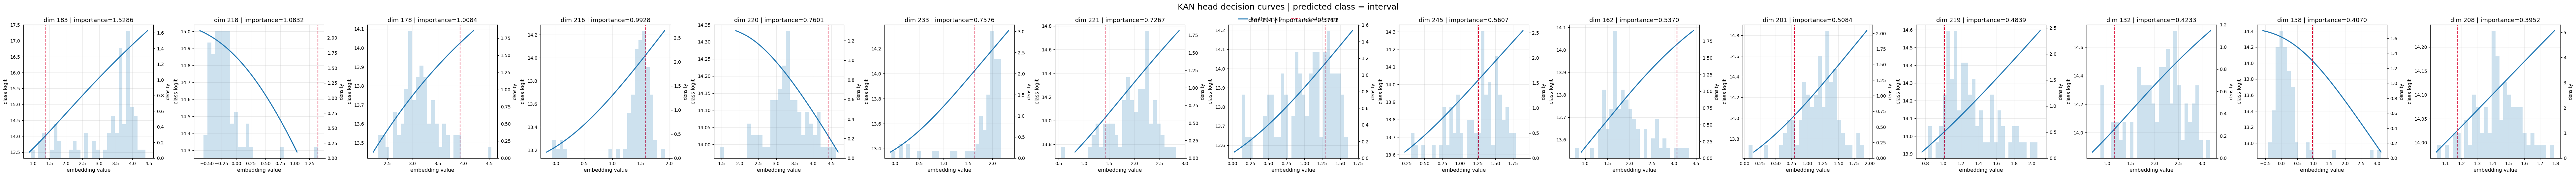

Top KAN dims = [183, 218, 178, 216, 220, 233, 221, 194, 245, 162, 201, 219, 132, 158, 208]


In [13]:
# Chọn graph để phân tích KAN head
analysis_raw = raw_attack if KAN_ANALYSIS_GRAPH == "attack" else raw_normal
analysis_data = data_attack if KAN_ANALYSIS_GRAPH == "attack" else data_normal
analysis_label_name = attack_label_name if KAN_ANALYSIS_GRAPH == "attack" else normal_label_name

# Tính importance ở input của KAN head
kan_info = compute_kan_head_dim_importance(
    model,
    analysis_data,
    device=DEVICE,
)

analysis_pred_name = ckpt_label_mapping.get(
    kan_info["pred_idx"],
    f'class_{kan_info["pred_idx"]}'
)

# Graph embedding của graph đang phân tích
base_g = get_graph_embedding(
    model,
    analysis_data,
    device=DEVICE,
)

# Background embeddings để vẽ histogram
bg_label = analysis_label_name if KAN_BG_SAME_LABEL_ONLY else None

bg_embs, bg_names = collect_embedding_background(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    target_label_name=bg_label,
    max_samples=KAN_BG_MAX_SAMPLES,
    device=DEVICE,
)

print("KAN analysis graph:", analysis_data.graph_id)
print("true label =", analysis_label_name)
print("pred label =", analysis_pred_name)
print("background embeddings shape =", bg_embs.shape)

top_dims, pred_name = plot_kan_head_top_dims(
    model=model,
    base_g=base_g,
    kan_info=kan_info,
    bg_embs=bg_embs,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    top_k=TOP_K_KAN_DIMS,
    figsize=(5.2 * TOP_K_KAN_DIMS, 4.8),
)

print("Top KAN dims =", top_dims.tolist())

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from typing import Dict, Any, Optional
import os

# --- CÁC HÀM TÍNH TOÁN (Giữ nguyên logic chuẩn của bạn) ---

def get_graph_embedding(model, data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        h = model.encode_nodes(data)
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)
    return g.detach().cpu()

def get_graph_embedding_with_grad(model, data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)
    return g

def compute_kan_head_dim_importance(model, data, device: str = "cpu"):
    model.eval()
    g = get_graph_embedding_with_grad(model, data, device=device)
    g = g.detach().clone().requires_grad_(True).to(device)

    logits = model.head(g)
    pred_idx = int(logits.argmax(dim=1).item())
    score = logits[0, pred_idx]

    grad = torch.autograd.grad(score, g, retain_graph=False, create_graph=False)[0]

    signed_effect = (grad * g).detach().cpu().numpy()[0]
    importance = np.abs(signed_effect)

    return {
        "pred_idx": pred_idx,
        "graph_embedding": g.detach().cpu(),   
        "importance": importance,              
        "signed_effect": signed_effect,        
        "grad": grad.detach().cpu().numpy()[0],
        "g_np": g.detach().cpu().numpy()[0],
        "logits_np": logits.detach().cpu().numpy()[0],
    }

def collect_embedding_background(
    model, graph_folder: Path, split: str, label_mapping: Dict[int, str],
    target_label_name: Optional[str] = None, max_samples: int = 80, device: str = "cpu"
):
    embs = []
    names = []
    # Giả định các hàm iter_raw_graphs, get_graph_label_name, normalize_label_name, graph_dict_to_data đã có
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if target_label_name is not None:
            if normalize_label_name(label_name) != normalize_label_name(target_label_name):
                continue
        data = graph_dict_to_data(raw_g)
        g = get_graph_embedding(model, data, device=device)
        embs.append(g.numpy()[0])
        names.append(label_name)
        if len(embs) >= max_samples:
            break

    if len(embs) == 0:
        raise ValueError("No background embeddings collected.")
    return np.stack(embs, axis=0), names

def sweep_one_embedding_dim_through_head(
    model, base_g: torch.Tensor, dim_idx: int, x_grid_np: np.ndarray, device: str = "cpu"
):
    model.eval()
    curves = []
    base_g = base_g.clone().detach().to(device)
    with torch.no_grad():
        for val in x_grid_np:
            g = base_g.clone()
            g[0, dim_idx] = float(val)
            logits = model.head(g)
            curves.append(logits.detach().cpu().numpy()[0])
    return np.stack(curves, axis=0)

def select_meaningful_dims(kan_info: Dict[str, Any], top_k: int = 3):
    signed_effect = np.asarray(kan_info["signed_effect"])
    importance = np.asarray(kan_info["importance"])
    used = []
    labels = []

    pos_idx = np.where(signed_effect > 0)[0]
    neg_idx = np.where(signed_effect < 0)[0]

    if len(pos_idx) > 0:
        i_pos = pos_idx[np.argmax(signed_effect[pos_idx])]
        used.append(int(i_pos))
        labels.append("Positive") # Đổi sang viết hoa cho đẹp
    if len(neg_idx) > 0:
        i_neg = neg_idx[np.argmin(signed_effect[neg_idx])]
        if int(i_neg) not in used:
            used.append(int(i_neg))
            labels.append("Negative")

    remaining = [i for i in np.argsort(importance)[::-1] if int(i) not in used]
    while len(used) < top_k and len(remaining) > 0:
        used.append(int(remaining.pop(0)))
        labels.append("Remaining")

    return np.array(used[:top_k], dtype=int), labels[:top_k]

# --- HÀM VẼ ĐỒ THỊ MỚI (Chuẩn học thuật) ---

def plot_kan_head_meaningful_dims(
    model, base_g: torch.Tensor, kan_info: Dict[str, Any], bg_embs: np.ndarray,
    label_mapping: Dict[int, str], device: str = "cpu", top_k: int = 3,
    figsize=(14, 4.5), save_path: Optional[str] = None
):
    # 1. Cấu hình Font chuẩn học thuật
    plt.rcParams.update({
        "axes.labelsize": 11,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.titlesize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    pred_idx = kan_info["pred_idx"]
    pred_name = label_mapping.get(pred_idx, f"class_{pred_idx}")
    importance = np.asarray(kan_info["importance"])
    signed_effect = np.asarray(kan_info["signed_effect"])

    top_dims, dim_roles = select_meaningful_dims(kan_info, top_k=top_k)

    fig, axes = plt.subplots(1, len(top_dims), figsize=figsize)
    if len(top_dims) == 1:
        axes = [axes]

    for ax, dim_idx, role in zip(axes, top_dims, dim_roles):
        vals = bg_embs[:, dim_idx]

        lo = np.quantile(vals, 0.01)
        hi = np.quantile(vals, 0.99)
        if hi <= lo:
            lo, hi = vals.min(), vals.max()
        if hi <= lo:
            hi = lo + 1e-3

        margin = max((hi - lo) * 0.08, 1e-3)
        x_grid = np.linspace(lo - margin, hi + margin, 240)

        curves = sweep_one_embedding_dim_through_head(
            model=model, base_g=base_g, dim_idx=int(dim_idx), x_grid_np=x_grid, device=device,
        )
        y_pred = curves[:, pred_idx]
        selected_val = float(base_g[0, dim_idx].item())

        # Vẽ đường cong KAN và giá trị mẫu hiện tại
        ax.plot(x_grid, y_pred, lw=2.5, color="#1f77b4", zorder=3)
        ax.axvline(selected_val, color="#d62728", linestyle="--", lw=1.8, zorder=4)

        # Trục phụ cho mật độ phân bố (Histogram)
        ax2 = ax.twinx()
        ax2.hist(vals, bins=30, density=True, color="lightgray", alpha=0.7, zorder=1)
        ax2.set_ylabel("Data Density", color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

        # Định dạng tiêu đề và trục gọn gàng, học thuật hơn
        sign_txt = "+" if signed_effect[dim_idx] > 0 else "-"
        ax.set_title(
            f"Dimension {dim_idx}\n(Role: {role} [{sign_txt}], |Effect|: {importance[dim_idx]:.3f})",
            fontweight='bold', pad=10
        )
        ax.set_xlabel("Embedding Value", fontweight='bold')
        ax.set_ylabel("Class Logit", color="#1f77b4", fontweight='bold')
        ax.tick_params(axis='y', labelcolor="#1f77b4")
        ax.grid(True, alpha=0.3, linestyle="--")

    # 2. Tạo Legend tổng hợp đặt dưới cùng (không đè lên đồ thị)
    handles = [
        Line2D([0], [0], color="#1f77b4", lw=2.5, label=f"KAN Function $\phi(x)$"),
        Line2D([0], [0], color="#d62728", lw=1.8, linestyle="--", label="Current Instance"),
        Patch(facecolor='lightgray', edgecolor='none', alpha=0.7, label="Data Distribution")
    ]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)

    plt.tight_layout()
    
    # 3. Lưu ảnh PDF chất lượng cao
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f"[*] Saved high-res meaningful KAN curves to: {save_path}")

    plt.show()
    plt.rcdefaults()

    return top_dims, dim_roles, pred_name

KAN analysis graph: interval__00052416_00052480
true label = interval
pred label = interval
background embeddings shape = (80, 256)
[*] Saved high-res meaningful KAN curves to: ../figures/explainability/meaningful_kan_curves.pdf


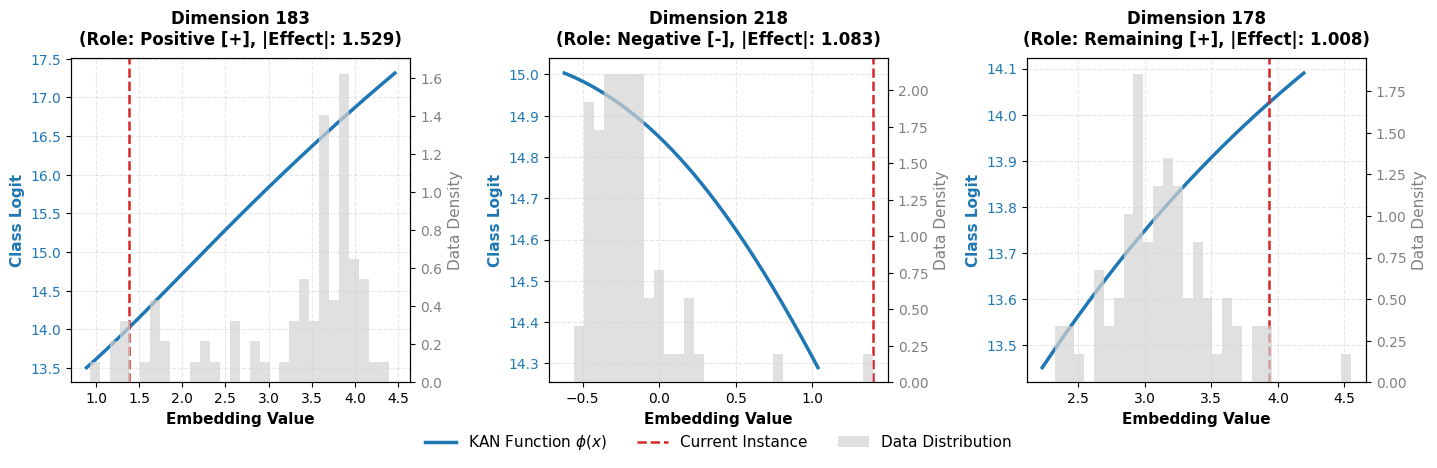


--- Summary ---
Selected dims = [183, 218, 178]
Roles = ['Positive', 'Negative', 'Remaining']


In [26]:
analysis_raw = raw_attack if KAN_ANALYSIS_GRAPH == "attack" else raw_normal
analysis_data = data_attack if KAN_ANALYSIS_GRAPH == "attack" else data_normal
analysis_label_name = attack_label_name if KAN_ANALYSIS_GRAPH == "attack" else normal_label_name

kan_info = compute_kan_head_dim_importance(
    model,
    analysis_data,
    device=DEVICE,
)

analysis_pred_name = ckpt_label_mapping.get(
    kan_info["pred_idx"],
    f'class_{kan_info["pred_idx"]}'
)

base_g = get_graph_embedding(
    model,
    analysis_data,
    device=DEVICE,
)

bg_label = analysis_label_name if KAN_BG_SAME_LABEL_ONLY else None

bg_embs, bg_names = collect_embedding_background(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    target_label_name=bg_label,
    max_samples=KAN_BG_MAX_SAMPLES,
    device=DEVICE,
)

print("KAN analysis graph:", analysis_data.graph_id)
print("true label =", analysis_label_name)
print("pred label =", analysis_pred_name)
print("background embeddings shape =", bg_embs.shape)

# Vẽ đồ thị sử dụng cấu hình mới
top_dims, dim_roles, pred_name = plot_kan_head_meaningful_dims(
    model=model,
    base_g=base_g,
    kan_info=kan_info,
    bg_embs=bg_embs,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    top_k=3,
    figsize=(14.5, 4.5),
    save_path="../figures/explainability/meaningful_kan_curves.pdf"
)

print("\n--- Summary ---")
print("Selected dims =", top_dims.tolist())
print("Roles =", dim_roles)


## Gợi ý diễn giải ngắn gọn cho 3 hình

### Hình 1 — Relation heatmap
- ô nào dương lớn hơn nghĩa là **bỏ relation đó đi thì score class đúng giảm mạnh hơn**
- relation nào sáng mạnh hơn ở một class cho thấy mô hình đang **dựa vào relation đó** nhiều hơn cho class đó

### Hình 2 — Node/Subgraph case study
- node màu đậm hơn nghĩa là **che node đó đi thì score class đích giảm mạnh hơn**
- nếu graph attack tập trung mạnh vào một cụm node hơn normal, đó là bằng chứng mô hình đang dùng **subgraph cục bộ** để phát hiện bất thường

### Hình 3 — KAN head decision curves
- mỗi panel cho biết **một embedding dimension quan trọng** tác động thế nào lên logit class được dự đoán
- đường cong phi tuyến cho thấy KAN head không chỉ cộng tuyến tính, mà có thể học **ngưỡng / bão hòa / vùng khuếch đại / vùng ức chế**
